## Sexta etapa

Em sexta_etapa.ipynb, utilizaremos dos registros que filtramos (ou não) em quinta_etapa.ipynb, e faremos a filtragem dos nomes científicos das exsicatas. De maneira similar aos taxonomistas, o nome científico das plantas é de suma importância para o treino correto de uma inteligência artificial. Erros de digitação e nomes sinônimos identificados pelo The Leipzig Catalogue of Vascular Plants (LCVP) serão unificados com um único nome.

Seguindo a mesma convenção da etapa anterior, o nome do novo campo será scientificname_att, pois o campo original é scientific_name. Também teremos status_plantas, um campo sem precedentes, para a identificação de nomes que já estavam corretos (accepted), nomes sinônimos que foram atualizados (synonym) e nomes que não foram encontrados no banco do LCVP (unresolved.)

Caso não deseje realizar essa filtragem, siga utilizando o campo scientificname ao invés de scientificname_att nas próximas filtragens.

In [1]:
from bibliotecas import *

specieslink, db_config = configurar()

In [2]:
conn = mysql_conn.connect(**db_config)
cursor = conn.cursor()

requisito = "country_att"
requisito2 = "stateprovince_att"
requisito3 = "barcode_att"
requisito4 = "identifiedby_att"
coluna = "scientificname"
table = "registros_biodiversidade"

sql = f"""SELECT {coluna} FROM {table} WHERE {coluna} IS NOT NULL AND {requisito} IS NOT NULL AND {requisito2} IS NOT NULL AND {requisito3} IS NOT NULL AND {requisito4} IS NOT NULL GROUP BY {coluna}"""

cursor.execute(sql)
resultados = cursor.fetchall()

cursor.close()
conn.close()

nomes = [r[0] for r in resultados if r[0]]

df = pd.DataFrame({"scientificname": nomes})

csv_buffer = StringIO()
df.to_csv(csv_buffer, index=False)
csv_buffer.seek(0)

0

In [3]:
tabela = "registros_biodiversidade"
coluna = input("informe o nome da coluna PRÉ-CRIADA que armazenará o NOVO nome científico das plantas: ").strip()
status = input("informe o nome da coluna PRÉ-CRIADA que armazenará o status do nome científico ATUAL das plantas: ").strip()
max_distance = input("informe a margem de erro máxima para erros gramaticais e afina (padrão 0.1): ").strip()
if max_distance:
    try:
        max_distance = float(max_distance)
        # print(f"executando sinonimos.perform_lcvp_fuzzy_search(--csv {csv} --txt {txt} --max_distance {max_distance})...\n")
    except ValueError:
        print("valor inválido para margem de erro. usando valor padrão de 0.1\n")
        max_distance = 0.1
else:
    max_distance = 0.1

    try:
        conn = mysql_conn.connect(**db_config)
        cursor = conn.cursor()

        for col in [coluna, status]:
                try:
                    cursor.execute(f"ALTER TABLE {tabela} ADD COLUMN {col} TEXT")
                    print(f"campo '{col}' criado com sucesso na tabela '{table}")
                except Exception:
                    pass 
        conn.commit()
        cursor.close()
        conn.close()
    except Exception as e:
        print(f"erro ao manipular colunas: {e}")

csv_buffer.seek(0)
lines = csv_buffer.read().splitlines()

# remove linhas vazias
lines = [line.strip() for line in lines if line.strip()]

# remove header se existir
if lines and lines[0].lower() in ("scientificname", "scientific_name"):
    lines = lines[1:]

if not lines:
    raise RuntimeError("CSV não contém nomes científicos válidos após limpeza")

csv_content = "\n".join(lines) + "\n"

with tempfile.NamedTemporaryFile(
    mode="w",
    suffix=".csv",
    delete=False,
    encoding="utf-8"
) as tmp:
    tmp.write(csv_content)
    tmp_path = tmp.name


print(f"executando sinonimos.perform_lcvp_fuzzy_search_per_line(--csv {tmp_path} --tabela {tabela} --coluna {coluna} --status {status})...\n")

fuzzy_line = perform_lcvp_fuzzy_search_per_line(
    csv_file=tmp_path, db_config=db_config, tabela=tabela, coluna=coluna, specieslink=specieslink, status=status, max_distance=max_distance
)
if fuzzy_line:
    print("\nverificando com o LCVP...")

os.remove(tmp_path)

executando sinonimos.perform_lcvp_fuzzy_search_per_line(--csv C:\Users\Dell\AppData\Local\Temp\tmp3ofumchl.csv --tabela registros_biodiversidade --coluna scientificname_att --status status_plantas)...

processando: Oxalis divaricata...
'Oxalis divaricata' tem pelo menos uma entrada com status 'accepted', não será atualizado
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET status_plantas = %s
                WHERE scientificname = %s
            
valores para UPDATE: ['accepted', 'Oxalis divaricata']
963 registro(s) atualizado(s).
conexão encerrada
processando: Oxalis psoraleoides insipida...
'Oxalis psoraleoides insipida' tem pelo menos uma entrada com status 'accepted', não será atualizado
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET status_plantas = %s
                WHERE scientificname = %s
            
valores para

R[write to console]: Error: splist should include only binomial names, please check the following names: 'Oxalis'



'Oxalis juruensis' tem pelo menos uma entrada com status 'accepted', não será atualizado
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET status_plantas = %s
                WHERE scientificname = %s
            
valores para UPDATE: ['accepted', 'Oxalis juruensis']
150 registro(s) atualizado(s).
conexão encerrada
processando: Oxalis...
erro ao processar 'Oxalis': Error: splist should include only binomial names, please check the following names: 'Oxalis'

processando: Oxalis corymbosa...
atualizando 'Oxalis corymbosa' para 'Oxalis debilis Kunth' por ter status 'synonym'
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET scientificname_att = %s
                WHERE scientificname = %s
            
valores para UPDATE: ['Oxalis debilis Kunth', 'Oxalis corymbosa']
25 registro(s) atualizado(s).
conexão encerrada
conexão bem-suce

R[write to console]: Error: splist should include only binomial names, please check the following names: 'Indet.'

R[write to console]: In addition: 
R[write to console]: Warning messages:

R[write to console]: 1: No match found for 'OXALIS JACOBINENSIS'. 

R[write to console]: 2: No match found for 'OXALIS WARMINGII'. 

R[write to console]: 3: No match found for 'OXALIS CORNICARPA'. 

R[write to console]: 4: No match found for 'OXALIS ITAMARAJUENSIS'. 

R[write to console]: 5: No match found for 'OXALIS MANDIOCANUM'. 

R[write to console]: 6: No match found for 'OXALIS ANIMARUM'. 



'Biophytum columbianum' tem pelo menos uma entrada com status 'accepted', não será atualizado
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET status_plantas = %s
                WHERE scientificname = %s
            
valores para UPDATE: ['accepted', 'Biophytum columbianum']
94 registro(s) atualizado(s).
conexão encerrada
processando: Indet....
erro ao processar 'Indet.': Error: splist should include only binomial names, please check the following names: 'Indet.'

processando: Oxalis alstonii var.lutzii...
'Oxalis alstonii var.lutzii' tem pelo menos uma entrada com status 'accepted', não será atualizado
conexão bem-sucedida
query gerada para UPDATE: 
                UPDATE teste_pipeline.registros_biodiversidade
                SET status_plantas = %s
                WHERE scientificname = %s
            
valores para UPDATE: ['accepted', 'Oxalis alstonii var.lutzii']
1 registro(s) atualizado(s).
conexão

In [4]:
conn = mysql_conn.connect(**db_config)
cursor = conn.cursor()

sql = """
SELECT
    COUNT(*) AS total_registros,
    SUM(country_att IS NOT NULL) AS com_country,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL) AS com_country_e_state,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL AND barcode_att IS NOT NULL) as com_country_state_e_barcode,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL AND barcode_att IS NOT NULL AND identifiedby_att IS NOT NULL) as com_country_state_barcode_e_identificador,
    SUM(country_att IS NOT NULL AND stateprovince_att IS NOT NULL AND barcode_att IS NOT NULL AND identifiedby_att IS NOT NULL AND status_plantas = "accepted" OR status_plantas = "synonym") as com_country_state_barcode_identificador_nome
FROM registros_biodiversidade
"""

cursor.execute(sql)
total_registros, registros_country, registros_country_state, registros_country_state_barcode, registros_country_state_barcode_e_identificador, registros_country_state_barcode_identificador_nome = cursor.fetchone()

cursor.close()
conn.close()

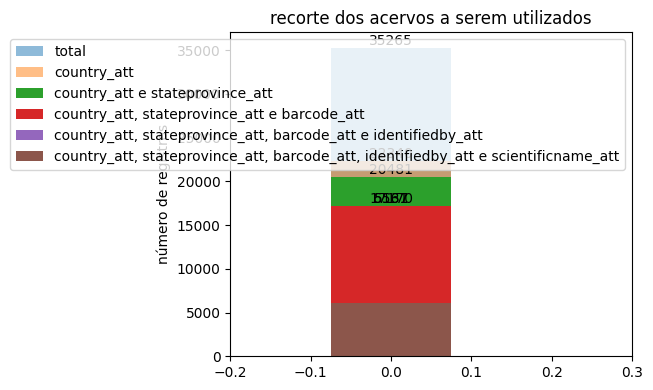

In [5]:
plt.figure(figsize=(6, 4))

x = [0]

plt.bar(
    x,
    [total_registros],
    alpha=0.5,
    width=0.15,
    label='total'
)

plt.bar(
    x,
    [registros_country],
    alpha=0.5,
    width=0.15,
    label='country_att'
)

plt.bar(
    x,
    [registros_country_state],
    width=0.15,
    label='country_att e stateprovince_att'
)

plt.bar(
    x,
    [registros_country_state_barcode],
    width=0.15,
    label='country_att, stateprovince_att e barcode_att'
)

plt.bar(
    x,
    [registros_country_state_barcode_e_identificador],
    width=0.15,
    label='country_att, stateprovince_att, barcode_att e identifiedby_att'
)

plt.bar(
    x,
    [registros_country_state_barcode_identificador_nome],
    width=0.15,
    label='country_att, stateprovince_att, barcode_att, identifiedby_att e scientificname_att'
)

plt.xlim(-0.2, 0.3)
plt.ylabel('número de registros')
plt.title('recorte dos acervos a serem utilizados')
plt.legend()

plt.text(0, total_registros, str(total_registros), ha='center', va='bottom')
plt.text(0, registros_country, str(registros_country), ha='center', va='bottom')
plt.text(0, registros_country_state, str(registros_country_state), ha='center', va='bottom')
plt.text(0, registros_country_state_barcode, str(registros_country_state_barcode), ha='center', va='bottom')
plt.text(0, registros_country_state_barcode, str(registros_country_state_barcode_e_identificador), ha='center', va='bottom')
plt.text(0, registros_country_state_barcode, str(registros_country_state_barcode_identificador_nome), ha='center', va='bottom')

plt.tight_layout()
plt.show()